In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/amanalisiddiqui/fraud-detection-dataset/AIML Dataset.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/amanalisiddiqui/fraud-detection-dataset/AIML Dataset.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## checking for unique values in the each column

In [8]:
df.nunique()

step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

In [9]:
for col in df.columns:
    print(f"{col} column has unique values {df[col].nunique()}")
    print(df[col].unique())
    print("*"*20)

step column has unique values 743
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 

## checking null values

In [10]:
df.isnull().sum()

#noticed that no null values in the dataset or columns

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [11]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [12]:
df.shape

(6362620, 11)

In [13]:
df.size

69988820

In [14]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [15]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

noticed that there is more imbalanced the data

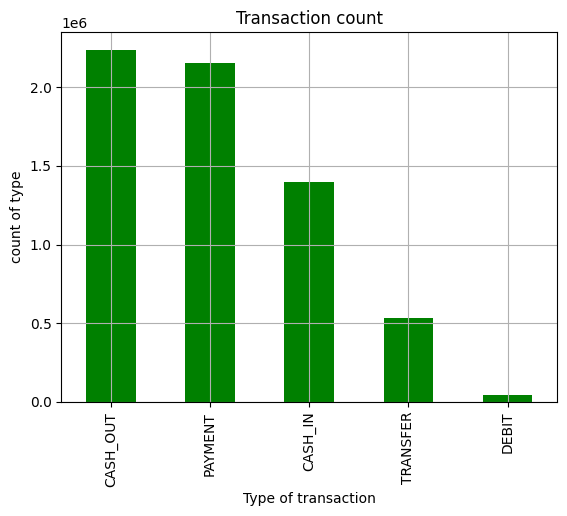

In [16]:
df['type'].value_counts().plot(kind = "bar", title = "Transaction count", color = "green")
plt.xlabel("Type of transaction")
plt.ylabel("count of type")
plt.grid(True)
plt.show()

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


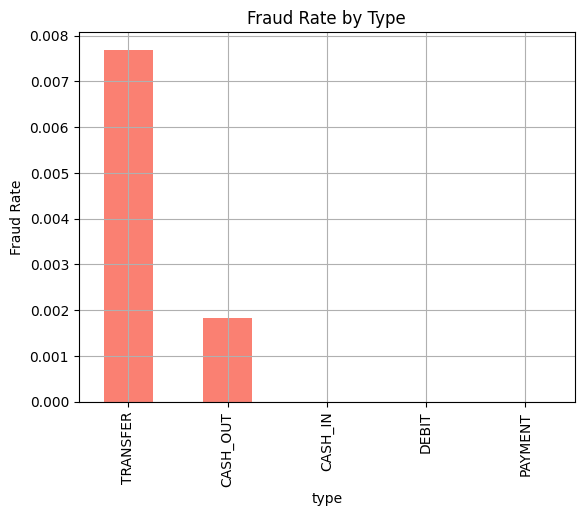

In [17]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending = False)
print(fraud_by_type)
fraud_by_type.plot(kind = "bar", title = "Fraud Rate by Type", color = "salmon")
plt.ylabel("Fraud Rate")
plt.grid(True)
plt.show()

In [18]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [19]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

insights from the amount column is mean values is less as compared to standard deviation

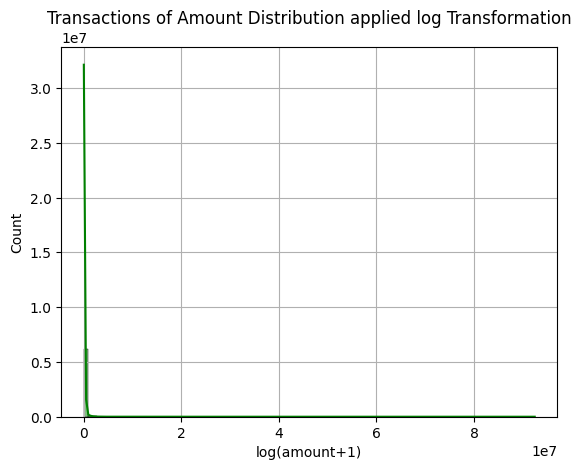

In [20]:
sns.histplot(df['amount'],bins = 100,kde = True, color = "green")
plt.title("Transactions of Amount Distribution applied log Transformation")
plt.xlabel("log(amount+1)")
plt.grid(True)
plt.show()

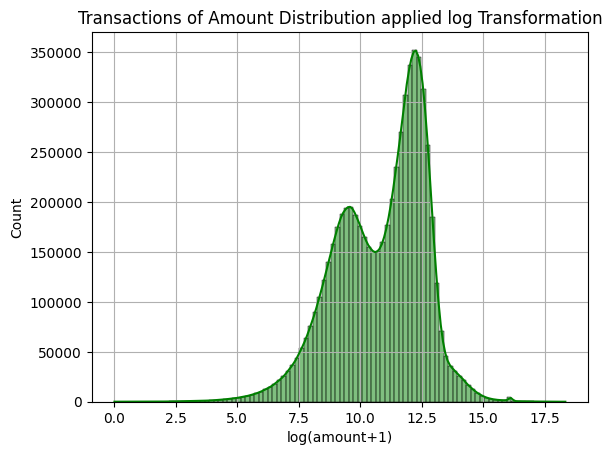

In [21]:
# np.log1p() means --- log(1+x) if value is 10 then log(11) is 2.39 :

sns.histplot(np.log1p(df['amount']),bins = 100,kde = True, color = "green")
plt.title("Transactions of Amount Distribution applied log Transformation")
plt.xlabel("log(amount+1)")
plt.grid(True)
plt.show()

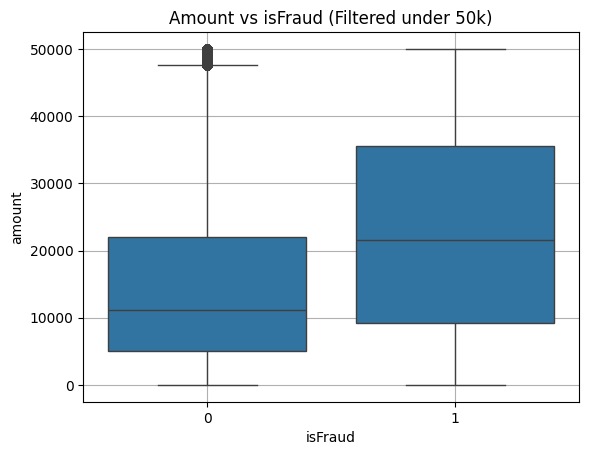

In [22]:
sns.boxplot(data = df[df['amount'] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.grid(True)
plt.show()

# insights from the boxplot
-- the normal transaction between 5000 to 22000 is considered as not fraud where the median is 11000 

-- similarly fraud to be considered from 9000 to 35000 where median is doubled the not fraud i.e  22000

-- and the outliers is there in not fraud that is 48000

In [23]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [24]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [25]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [26]:
# checking for the negative values in the balance diff origin

print((df['balanceDiffOrig'] < 0 ).sum())

1399253


In [27]:
# checking for the negative values in the balance differenct from destionation

print((df['balanceDiffDest'] <0).sum())

1238864


741
********************


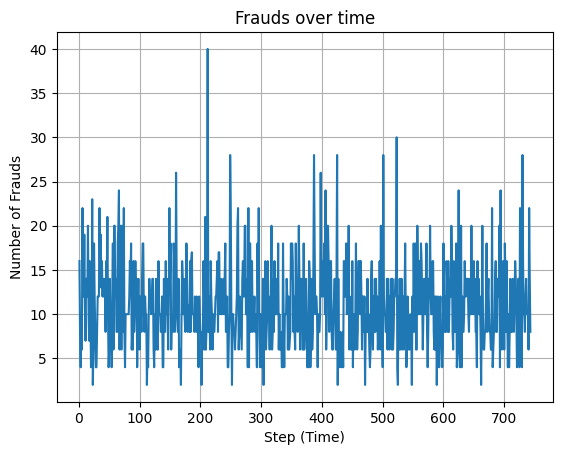

In [28]:
frauds_per_step = df[df['isFraud'] == 1]["step"].value_counts().sort_index()
print(frauds_per_step.count())
print("*"*20)
# print(frauds_per_step.values)
plt.plot(frauds_per_step.index, frauds_per_step.values, label = "Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds over time")
plt.grid(True)
plt.show()

In [29]:
df.drop(columns = "step", inplace = True)

In [30]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [31]:
top_senders = df['nameOrig'].value_counts().head()
print(top_senders)

nameOrig
C1530544995    3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
Name: count, dtype: int64


In [32]:
top_receiver = df['nameDest'].value_counts().head()

print(top_receiver)

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
Name: count, dtype: int64


In [33]:
fraud_users = df[df['isFraud']==1]['nameOrig'].value_counts()
print(fraud_users)
print(fraud_users.count())

nameOrig
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
              ..
C1134864869    1
C1984954272    1
C1247938090    1
C2126545173    1
C7162498       1
Name: count, Length: 8213, dtype: int64
8213


In [34]:
notfraud_users = df[df['isFraud']==0]['nameOrig'].value_counts()
print(fraud_users)
print(fraud_users.count())

nameOrig
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
              ..
C1134864869    1
C1984954272    1
C1247938090    1
C2126545173    1
C7162498       1
Name: count, Length: 8213, dtype: int64
8213


In [35]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


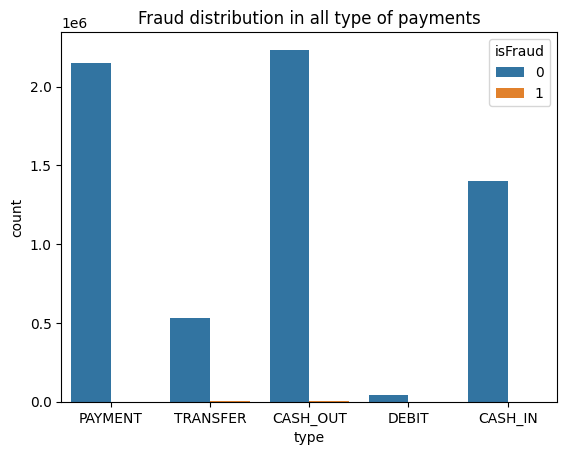

In [36]:
fraud_types = df[df["type"].isin(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'])]

print(fraud_types['type'].value_counts())

sns.countplot(data = fraud_types, x = "type", hue = "isFraud")
plt.title("Fraud distribution in all type of payments")
# plt.grid(True)
plt.show()



In [37]:
corr = df.corr(numeric_only = True)
print(corr)

                   amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
amount           1.000000      -0.002762       -0.007861        0.294137   
oldbalanceOrg   -0.002762       1.000000        0.998803        0.066243   
newbalanceOrig  -0.007861       0.998803        1.000000        0.067812   
oldbalanceDest   0.294137       0.066243        0.067812        1.000000   
newbalanceDest   0.459304       0.042029        0.041837        0.976569   
isFraud          0.076688       0.010154       -0.008148       -0.005885   
isFlaggedFraud   0.012295       0.003835        0.003776       -0.000513   
balanceDiffOrig  0.102337      -0.220297       -0.267750       -0.047460   
balanceDiffDest  0.845964      -0.087032       -0.094456        0.232316   

                 newbalanceDest   isFraud  isFlaggedFraud  balanceDiffOrig  \
amount                 0.459304  0.076688        0.012295         0.102337   
oldbalanceOrg          0.042029  0.010154        0.003835        -0.220297   
newba

<Axes: >

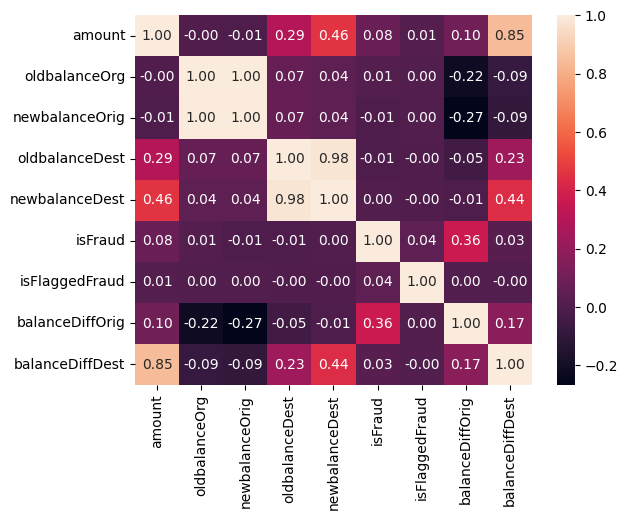

In [38]:
sns.heatmap(corr, fmt = ".2f", annot = True)

In [44]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]

In [45]:
len(zero_after_transfer)

1188074

In [41]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest


In [46]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## model training

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [49]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [50]:
df = df.drop(columns = ['nameOrig', "nameDest", "isFlaggedFraud"], axis = 1)


In [51]:
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [52]:
df.columns

Index(['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [53]:
categorical = ['type']

numerical = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest','newbalanceDest']

In [54]:
X = df.drop(columns = ["isFraud"], axis = 1)
y = df["isFraud"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify = y, random_state = 42)

In [56]:
preprocessor = ColumnTransformer(
    transformers =[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ], 
    remainder = "drop"
)

In [57]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight = "balanced", max_iter = 1000))
])

In [58]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [59]:
y_pred = pipeline.predict(X_test)

In [67]:
print(f"{accuracy_score(y_test, y_pred) * 100:.2f}")

94.67


In [62]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97   1804974
           1       0.94      0.02      0.04    103812

    accuracy                           0.95   1908786
   macro avg       0.94      0.51      0.51   1908786
weighted avg       0.95      0.95      0.92   1908786



In [68]:
confusion_matrix(y_test, y_pred)

array([[1804823,  101499],
       [    151,    2313]])

In [70]:
pipeline.score(X_test, y_test)*100

94.67462565211606

In [72]:
import joblib

joblib.dump(pipeline, "Fraud_detection_pipeline.pkl")

['Fraud_detection_pipeline.pkl']

In [73]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 96.5 MB/s eta 0:00:00:00:01


In [82]:
import streamlit as st
import sklearn
print(st.__version__)
print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)

1.55.0
2.0.2
2.3.3
1.6.1
